# 📊 Análisis de Ventas y Marketing — SynthData

**Autor:** Jonathan Monserrat  
**Fecha:** 2026  
**Stack:** Python · Pandas · Matplotlib · Seaborn · Plotly

---

## Contexto del negocio

SynthData es una empresa de retail con presencia en múltiples ciudades de Argentina que comercializa productos en tres categorías: **Electrónica**, **Electrodomésticos** y **Decoración**.

Este análisis integra tres fuentes de datos internas:

- **Ventas** (3.035 transacciones en 2024)
- **Campañas de marketing** (90 campañas en canales TV, RRSS y Email)
- **Clientes** (567 perfiles con datos demográficos)

### Preguntas de negocio que guían el análisis

1. ¿Cuáles son los productos y categorías con mayor volumen de ventas e ingresos?
2. ¿Existe estacionalidad en las ventas a lo largo del año?
3. ¿Qué canal de marketing genera mejor relación entre costo de campaña y ventas del producto?
4. ¿Hay correlación entre el precio de un producto y la cantidad vendida?
5. ¿Qué perfil demográfico concentra mayor poder de compra?

---


## 0. Configuración del entorno


In [ ]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn plotly openpyxl

> **Nota:** La celda anterior instala las dependencias necesarias 
> directamente en el entorno virtual activo. Si ya las instalaste 
> previamente desde la terminal con `pip install`, podés omitir 
> esta celda.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# Estilo visual consistente para matplotlib/seaborn
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('muted')

print('✅ Librerías cargadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ Librerías cargadas correctamente
   pandas  3.0.1
   numpy   2.4.3
   seaborn 0.13.2


---

## 1. Carga de datos


In [ ]:
# Carga de los tres datasets
ventas    = pd.read_csv('ventas.csv')
marketing = pd.read_csv('marketing.csv')
clientes  = pd.read_csv('clientes.csv')

print('Datasets cargados:')
print(f'  ventas    → {ventas.shape[0]:,} filas × {ventas.shape[1]} columnas')
print(f'  marketing → {marketing.shape[0]:,} filas × {marketing.shape[1]} columnas')
print(f'  clientes  → {clientes.shape[0]:,} filas × {clientes.shape[1]} columnas')

Datasets cargados:
  ventas    → 3,035 filas × 6 columnas
  marketing → 90 filas × 6 columnas
  clientes  → 567 filas × 5 columnas


---

## 2. Exploración inicial (EDA)

Antes de limpiar, es fundamental entender qué tenemos: estructura, tipos de datos, rango de valores y primeras señales de problemas.


In [4]:
print('=== VENTAS ===')
print(ventas.info())
print()
ventas.head()

=== VENTAS ===
<class 'pandas.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     3035 non-null   int64  
 1   producto     3035 non-null   str    
 2   precio       3033 non-null   str    
 3   cantidad     3033 non-null   float64
 4   fecha_venta  3035 non-null   str    
 5   categoria    3035 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 142.4 KB
None



,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos


In [5]:
print('=== MARKETING ===')
print(marketing.info())
print()
marketing.head()

=== MARKETING ===
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_campanha   90 non-null     int64  
 1   producto      90 non-null     str    
 2   canal         90 non-null     str    
 3   costo         90 non-null     float64
 4   fecha_inicio  90 non-null     str    
 5   fecha_fin     90 non-null     str    
dtypes: float64(1), int64(1), str(4)
memory usage: 4.3 KB
None



,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024


In [6]:
print('=== CLIENTES ===')
print(clientes.info())
print()
clientes.head()

=== CLIENTES ===
<class 'pandas.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  567 non-null    int64  
 1   nombre      567 non-null    str    
 2   edad        567 non-null    int64  
 3   ciudad      567 non-null    str    
 4   ingresos    567 non-null    float64
dtypes: float64(1), int64(2), str(2)
memory usage: 22.3 KB
None



,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65


In [7]:
# Resumen estadístico de variables numéricas
print('📊 Estadística descriptiva — clientes')
clientes[['edad', 'ingresos']].describe().round(2)

📊 Estadística descriptiva — clientes


,edad,ingresos
count,567.00,567.00
mean,37.94,34668.74
std,10.20,12974.53
min,20.00,170.29
25%,30.00,26015.24
50%,37.00,35066.83
75%,43.00,42457.10
max,81.00,88053.01


### 2.1 Diagnóstico de calidad de datos


In [8]:
def diagnostico_calidad(df, nombre):
    """Genera un resumen de calidad para un DataFrame."""
    total = len(df)
    nulos = df.isnull().sum()
    duplicados = df.duplicated().sum()
    
    print(f'\n{'='*45}')
    print(f' Dataset: {nombre} ({total:,} filas)')
    print(f'{'='*45}')
    print(f' Duplicados: {duplicados} ({duplicados/total*100:.1f}%)')
    print(f' Valores nulos por columna:')
    for col, n in nulos.items():
        pct = n / total * 100
        estado = '⚠️' if n > 0 else '✅'
        print(f'   {estado} {col}: {n} ({pct:.1f}%)')
    
    # Problemas de formato detectados
    if nombre == 'ventas':
        precio_con_signo = df['precio'].astype(str).str.startswith('$').sum()
        print(f'\n Formato de precio: {precio_con_signo} valores con signo "$" → requiere limpieza')

    # Detectar columnas de fecha almacenadas como texto
    columnas_fecha = [col for col in df.columns if 'fecha' in col.lower()]
    for col in columnas_fecha:
        if df[col].dtype == 'string' or df[col].dtype == 'object':
            print(f'\n Columna "{col}": tipo texto → requiere conversión a datetime')
        else:
            print(f'\n Columna "{col}": tipo {df[col].dtype} ✅')

diagnostico_calidad(ventas, 'ventas')
diagnostico_calidad(marketing, 'marketing')
diagnostico_calidad(clientes, 'clientes')


 Dataset: ventas (3,035 filas)
 Duplicados: 35 (1.2%)
 Valores nulos por columna:
   ✅ id_venta: 0 (0.0%)
   ✅ producto: 0 (0.0%)
   ⚠️ precio: 2 (0.1%)
   ⚠️ cantidad: 2 (0.1%)
   ✅ fecha_venta: 0 (0.0%)
   ✅ categoria: 0 (0.0%)

 Formato de precio: 3033 valores con signo "$" → requiere limpieza

 Columna "fecha_venta": tipo texto → requiere conversión a datetime

 Dataset: marketing (90 filas)
 Duplicados: 0 (0.0%)
 Valores nulos por columna:
   ✅ id_campanha: 0 (0.0%)
   ✅ producto: 0 (0.0%)
   ✅ canal: 0 (0.0%)
   ✅ costo: 0 (0.0%)
   ✅ fecha_inicio: 0 (0.0%)
   ✅ fecha_fin: 0 (0.0%)

 Columna "fecha_inicio": tipo texto → requiere conversión a datetime

 Columna "fecha_fin": tipo texto → requiere conversión a datetime

 Dataset: clientes (567 filas)
 Duplicados: 0 (0.0%)
 Valores nulos por columna:
   ✅ id_cliente: 0 (0.0%)
   ✅ nombre: 0 (0.0%)
   ✅ edad: 0 (0.0%)
   ✅ ciudad: 0 (0.0%)
   ✅ ingresos: 0 (0.0%)


---

## 3. Limpieza y preprocesamiento

Documentamos cada decisión de limpieza con su justificación.


In [29]:
# ── VENTAS ──────────────────────────────────────────

ventas_clean = ventas.copy()

# 1. Eliminar duplicados
n_antes = len(ventas_clean)
ventas_clean = ventas_clean.drop_duplicates()
print(f'Duplicados eliminados: {n_antes - len(ventas_clean)}')

# 2. Eliminar filas con nulos en precio o cantidad
#    Decisión: son solo 2 filas sobre 3035 (0.06%), impacto insignificante.
n_antes = len(ventas_clean)
ventas_clean = ventas_clean.dropna(subset=['precio', 'cantidad'])
print(f'Filas con nulos eliminadas: {n_antes - len(ventas_clean)}')

# 3. Limpiar columna precio: remover el signo $ y convertir a float
#    Decisión: el signo es un problema de formato en el origen, no un dato inválido.
ventas_clean['precio'] = (
    ventas_clean['precio']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.strip()
    .astype(float)
)

# 4. Convertir fechas al tipo datetime
ventas_clean['fecha_venta'] = pd.to_datetime(ventas_clean['fecha_venta'], dayfirst=True)

# 5. Crear columnas derivadas útiles para el análisis
ventas_clean['mes']           = ventas_clean['fecha_venta'].dt.to_period('M')
ventas_clean['mes_num']       = ventas_clean['fecha_venta'].dt.month
meses_es = ['enero','febrero','marzo','abril','mayo','junio',
            'julio','agosto','septiembre','octubre','noviembre','diciembre']
ventas_clean['mes_nombre'] = ventas_clean['fecha_venta'].dt.month.apply(lambda x: meses_es[x-1])
ventas_clean['ingreso_total'] = ventas_clean['precio'] * ventas_clean['cantidad']

print(f'\nVentas limpias: {len(ventas_clean):,} filas')
print(f'Rango de fechas: {ventas_clean["fecha_venta"].min().date()} → {ventas_clean["fecha_venta"].max().date()}')
ventas_clean.head(3)

Duplicados eliminados: 35
Filas con nulos eliminadas: 2

Ventas limpias: 2,998 filas
Rango de fechas: 2024-01-02 → 2024-12-30


,id_venta,producto,precio,cantidad,fecha_venta,categoria,mes,mes_num,mes_nombre,ingreso_total
0,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,2024-01,1,enero,349.70
1,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,2024-01,1,enero,525.50
2,1156,Secadora,97.96,3.0,2024-01-02,Electrodomésticos,2024-01,1,enero,293.88


In [10]:
# ── MARKETING ───────────────────────────────────────

marketing_clean = marketing.copy()

# 1. Eliminar duplicados
n_antes = len(marketing_clean)
marketing_clean = marketing_clean.drop_duplicates()
print(f'Duplicados eliminados: {n_antes - len(marketing_clean)}')

# 2. Convertir fechas
marketing_clean['fecha_inicio'] = pd.to_datetime(marketing_clean['fecha_inicio'], dayfirst=True)
marketing_clean['fecha_fin']    = pd.to_datetime(marketing_clean['fecha_fin'], dayfirst=True)

# 3. Calcular duración de cada campaña en días
marketing_clean['duracion_dias'] = (
    marketing_clean['fecha_fin'] - marketing_clean['fecha_inicio']
).dt.days

print(f'\nMarketing limpio: {len(marketing_clean):,} filas')
marketing_clean.head(3)

Duplicados eliminados: 0

Marketing limpio: 90 filas


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin,duracion_dias
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,44
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13,48
2,32,Lámpara de mesa,Email,5.54,2024-03-28,2024-04-20,23


In [11]:
# ── CLIENTES ────────────────────────────────────────

clientes_clean = clientes.copy()

# 1. Eliminar duplicados
n_antes = len(clientes_clean)
clientes_clean = clientes_clean.drop_duplicates()
print(f'Duplicados eliminados: {n_antes - len(clientes_clean)}')

# 2. Crear segmento etario (útil para análisis demográfico)
bins   = [0, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']
clientes_clean['segmento_edad'] = pd.cut(
    clientes_clean['edad'], bins=bins, labels=labels, right=True
)

print(f'\nClientes limpios: {len(clientes_clean):,} filas')
print('\nDistribución por segmento:')
print(clientes_clean['segmento_edad'].value_counts().sort_index())

Duplicados eliminados: 0

Clientes limpios: 567 filas

Distribución por segmento:
segmento_edad
18-25     49
26-35    202
36-45    208
46-60     89
60+       19
Name: count, dtype: int64


---

## 4. Análisis de ventas

### 4.1 Ventas mensuales — ¿hay estacionalidad?


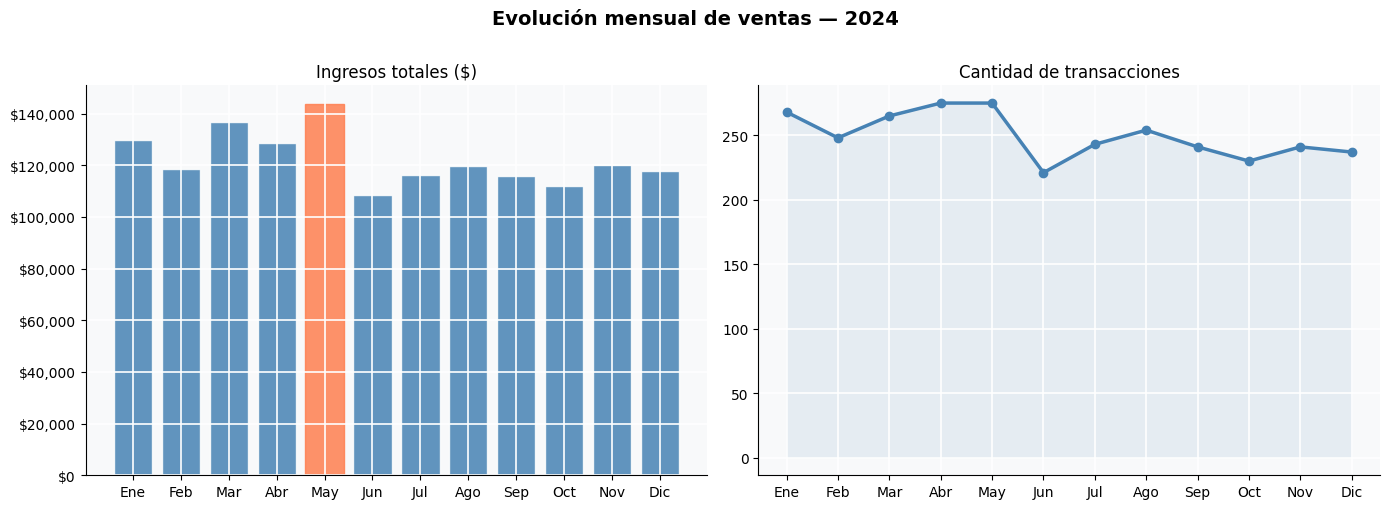


Mes de mayor ingreso: May ($143,727)
Ingreso total anual: $1,467,094


In [12]:
ventas_mensuales = (
    ventas_clean
    .groupby('mes_num')
    .agg(
        ingresos=('ingreso_total', 'sum'),
        transacciones=('id_venta', 'count')
    )
    .reset_index()
)

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ventas_mensuales['mes_label'] = ventas_mensuales['mes_num'].apply(lambda x: meses[x-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolución mensual de ventas — 2024', fontsize=14, fontweight='bold', y=1.01)

# Ingresos
bars = ax1.bar(ventas_mensuales['mes_label'], ventas_mensuales['ingresos'],
               color='steelblue', alpha=0.85, edgecolor='white')
ax1.set_title('Ingresos totales ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
# Resaltar el mes pico
max_idx = ventas_mensuales['ingresos'].idxmax()
bars[max_idx].set_color('coral')
ax1.set_xlabel('')

# Transacciones
ax2.plot(ventas_mensuales['mes_label'], ventas_mensuales['transacciones'],
         marker='o', linewidth=2.5, color='steelblue', markersize=6)
ax2.fill_between(range(len(ventas_mensuales)), ventas_mensuales['transacciones'],
                 alpha=0.1, color='steelblue')
ax2.set_title('Cantidad de transacciones')
ax2.set_xticks(range(len(ventas_mensuales)))
ax2.set_xticklabels(ventas_mensuales['mes_label'])

plt.tight_layout()
plt.savefig('ventas_mensuales.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMes de mayor ingreso: {meses[max_idx]} (${ventas_mensuales.loc[max_idx,'ingresos']:,.0f})")
print(f"Ingreso total anual: ${ventas_mensuales['ingresos'].sum():,.0f}")

### 4.2 Ventas por categoría


        categoria  ingresos  unidades  transacciones  ticket_promedio  participacion_%
Electrodomésticos 505299.63    6592.0           1000           505.30             34.4
      Electrónica 482577.80    6413.0            998           483.54             32.9
       Decoración 479216.09    6490.0           1000           479.22             32.7


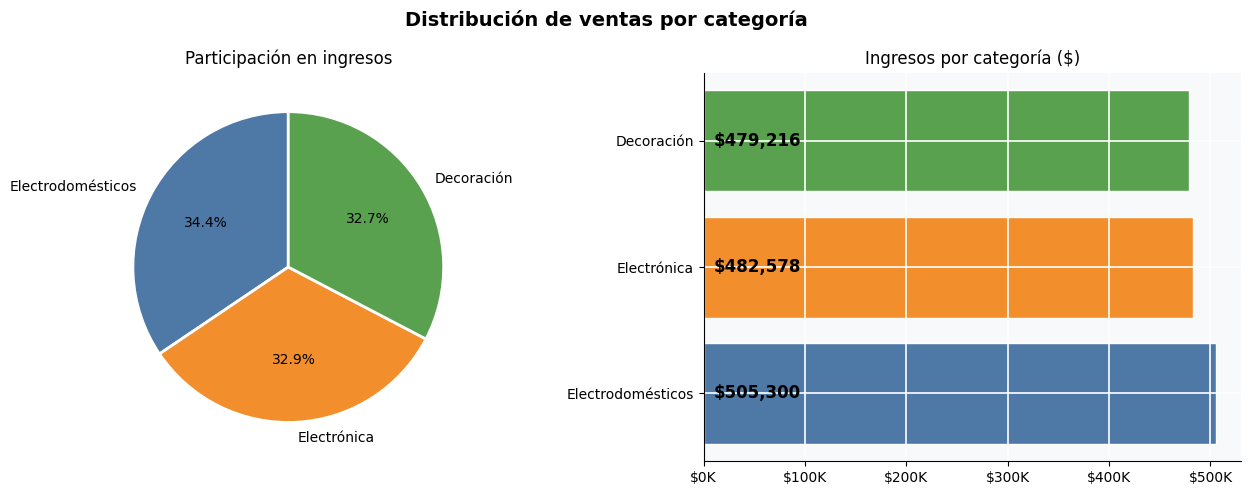

In [13]:
por_categoria = (
    ventas_clean
    .groupby('categoria')
    .agg(
        ingresos=('ingreso_total', 'sum'),
        unidades=('cantidad', 'sum'),
        transacciones=('id_venta', 'count'),
        ticket_promedio=('ingreso_total', 'mean')
    )
    .round(2)
    .sort_values('ingresos', ascending=False)
    .reset_index()
)

por_categoria['participacion_%'] = (por_categoria['ingresos'] / por_categoria['ingresos'].sum() * 100).round(1)
print(por_categoria.to_string(index=False))

# Gráfico de torta + barras
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribución de ventas por categoría', fontsize=14, fontweight='bold')

colores = ['#4e79a7', '#f28e2b', '#59a14f']

ax1.pie(por_categoria['ingresos'], labels=por_categoria['categoria'],
        autopct='%1.1f%%', colors=colores, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Participación en ingresos')

bars = ax2.barh(por_categoria['categoria'], por_categoria['ingresos'],
                color=colores, edgecolor='white')
ax2.set_title('Ingresos por categoría ($)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for bar, val in zip(bars, por_categoria['ingresos']):
    ax2.text(val * 0.02, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=12, color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('ventas_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Top 10 productos por ingreso


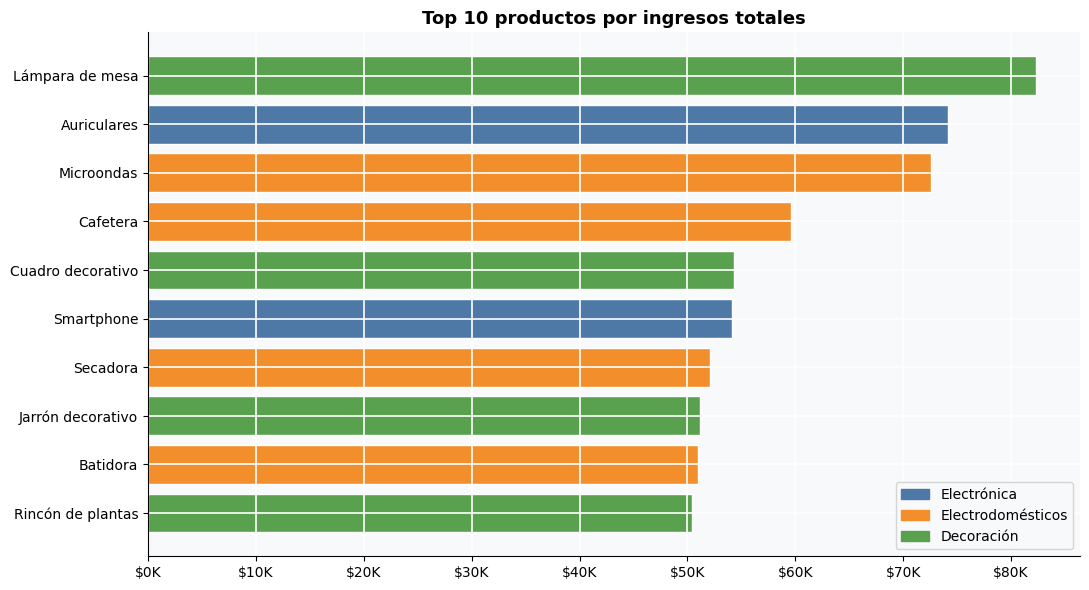

In [14]:
top_productos = (
    ventas_clean
    .groupby(['producto', 'categoria'])
    .agg(ingresos=('ingreso_total', 'sum'), unidades=('cantidad', 'sum'))
    .sort_values('ingresos', ascending=False)
    .head(10)
    .reset_index()
)

color_map = {'Electrónica': '#4e79a7', 'Electrodomésticos': '#f28e2b', 'Decoración': '#59a14f'}
colores_top = [color_map[c] for c in top_productos['categoria']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_productos['producto'], top_productos['ingresos'],
               color=colores_top, edgecolor='white')
ax.set_title('Top 10 productos por ingresos totales', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.invert_yaxis()

# Leyenda manual por categoría
from matplotlib.patches import Patch
leyenda = [Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=leyenda, loc='lower right')

plt.tight_layout()
plt.savefig('top_productos.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 5. Estadística descriptiva

### 5.1 Medidas de tendencia central y dispersión


In [15]:
def estadistica_completa(serie, nombre):
    """Calcula medidas de tendencia central y dispersión."""
    stats = {
        'Variable'          : nombre,
        'Media'             : serie.mean(),
        'Mediana'           : serie.median(),
        'Moda'              : serie.mode()[0],
        'Desv. estándar'    : serie.std(),
        'Varianza'          : serie.var(),
        'Mínimo'            : serie.min(),
        'Máximo'            : serie.max(),
        'Rango'             : serie.max() - serie.min(),
        'Q1 (25%)'          : serie.quantile(0.25),
        'Q3 (75%)'          : serie.quantile(0.75),
        'IQR'               : serie.quantile(0.75) - serie.quantile(0.25),
        'Coef. variación %' : (serie.std() / serie.mean() * 100),
    }
    return stats

stats_precio   = estadistica_completa(ventas_clean['precio'], 'Precio unitario ($)')
stats_cantidad = estadistica_completa(ventas_clean['cantidad'], 'Cantidad vendida')
stats_ingreso  = estadistica_completa(ventas_clean['ingreso_total'], 'Ingreso por transacción ($)')

df_stats = pd.DataFrame([stats_precio, stats_cantidad, stats_ingreso]).set_index('Variable').T
df_stats = df_stats.map(lambda x: f'{x:,.2f}')
print(df_stats.to_string())

Variable          Precio unitario ($) Cantidad vendida Ingreso por transacción ($)
Media                           75.29             6.50                      489.36
Mediana                         75.20             7.00                      418.06
Moda                            29.77            11.00                      345.33
Desv. estándar                  28.74             3.46                      334.28
Varianza                       825.76            11.94                  111,744.33
Mínimo                          26.00             1.00                       26.30
Máximo                         124.97            12.00                    1,488.12
Rango                           98.97            11.00                    1,461.82
Q1 (25%)                        50.03             3.00                      220.92
Q3 (75%)                       100.07             9.00                      709.92
IQR                             50.04             6.00                      489.00
Coef

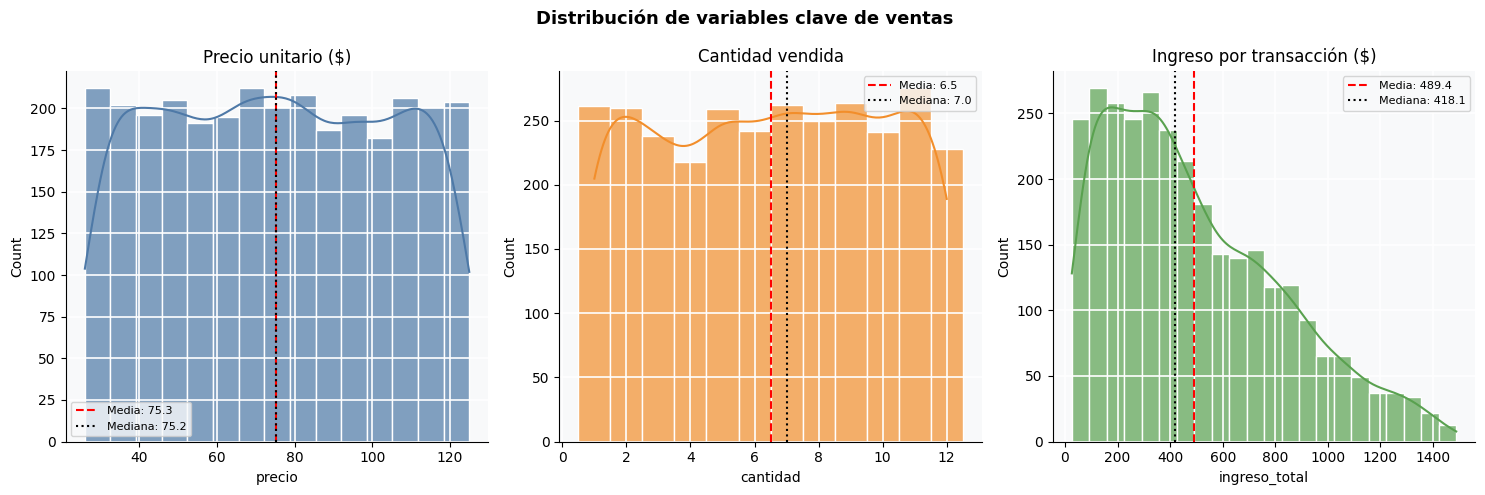

In [16]:
# Distribución de precios y cantidades con Seaborn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribución de variables clave de ventas', fontsize=13, fontweight='bold')

variables = [
    (ventas_clean['precio'],        'Precio unitario ($)',           '#4e79a7', False),
    (ventas_clean['cantidad'],      'Cantidad vendida',              '#f28e2b', True),
    (ventas_clean['ingreso_total'], 'Ingreso por transacción ($)',   '#59a14f', False),
]

for ax, (data, titulo, color, discreto) in zip(axes, variables):
    sns.histplot(data, kde=True, ax=ax, color=color, alpha=0.7,
                 edgecolor='white', discrete=discreto)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='black', linestyle=':', linewidth=1.5, label=f'Mediana: {data.median():.1f}')
    ax.set_title(titulo)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

**Observación:** La distribución de cantidad vendida muestra
picos en valores específicos (1-2, 5, 8-9, 11-12) con valles
en 6-7 unidades. Esto podría indicar la existencia de
promociones por volumen o packaging en cantidades fijas.
Se recomienda validar con el área comercial.


---

## 6. Análisis de correlación

### 6.1 Precio vs. cantidad vendida


Matriz de correlación:
               precio  cantidad  ingreso_total
precio          1.000    -0.002          0.559
cantidad       -0.002     1.000          0.773
ingreso_total   0.559     0.773          1.000


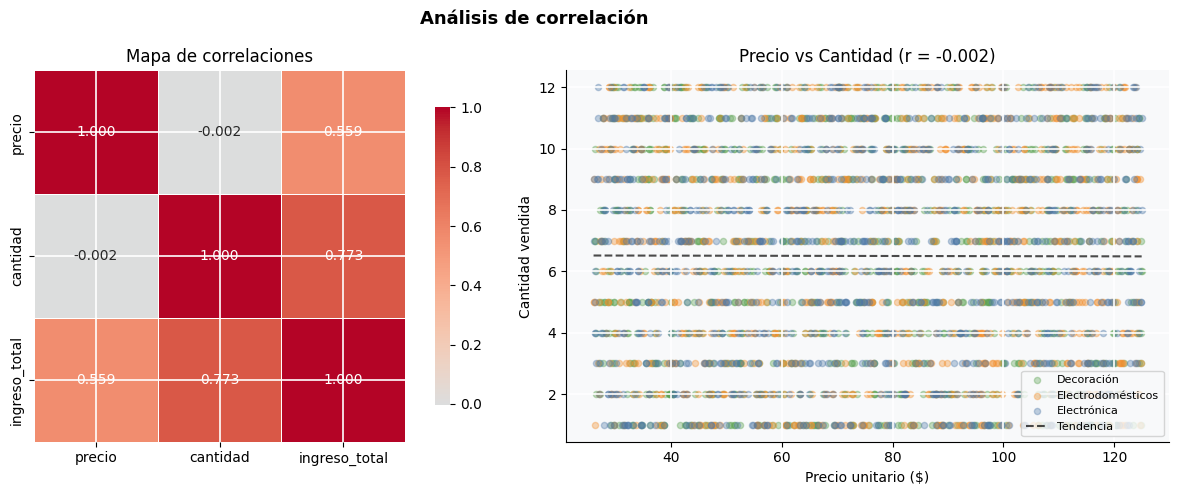

In [17]:
corr = ventas_clean[['precio', 'cantidad', 'ingreso_total']].corr()
print('Matriz de correlación:')
print(corr.round(3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Análisis de correlación', fontsize=13, fontweight='bold')

# Heatmap
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=ax1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax1.set_title('Mapa de correlaciones')

# Scatter precio vs cantidad por categoría
color_map = {'Electrónica': '#4e79a7', 'Electrodomésticos': '#f28e2b', 'Decoración': '#59a14f'}
for cat, grupo in ventas_clean.groupby('categoria'):
    ax2.scatter(grupo['precio'], grupo['cantidad'],
                alpha=0.35, s=20, label=cat, color=color_map[cat])

# Línea de tendencia
z = np.polyfit(ventas_clean['precio'], ventas_clean['cantidad'], 1)
p = np.poly1d(z)
x_line = np.linspace(ventas_clean['precio'].min(), ventas_clean['precio'].max(), 100)
ax2.plot(x_line, p(x_line), 'k--', linewidth=1.5, alpha=0.7, label='Tendencia')

ax2.set_xlabel('Precio unitario ($)')
ax2.set_ylabel('Cantidad vendida')
ax2.set_title(f'Precio vs Cantidad (r = {corr.loc["precio","cantidad"]:.3f})')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7. Visualizaciones avanzadas con Seaborn


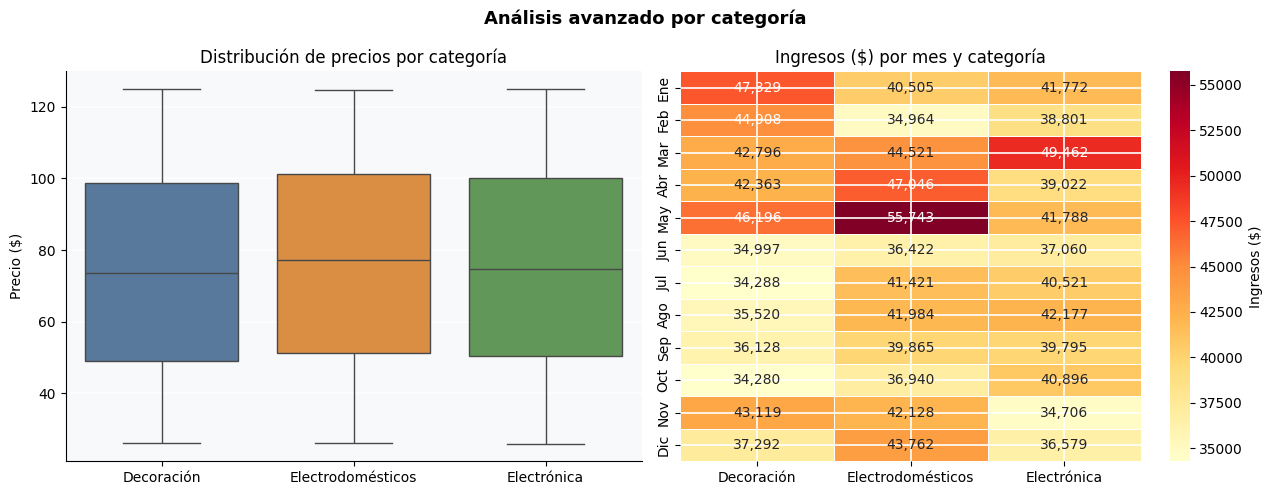

In [18]:
# Boxplot: distribución de precios por categoría
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Análisis avanzado por categoría', fontsize=13, fontweight='bold')

sns.boxplot(data=ventas_clean, x='categoria', y='precio',
            palette=['#4e79a7', '#f28e2b', '#59a14f'], ax=ax1,
            flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})
ax1.set_title('Distribución de precios por categoría')
ax1.set_xlabel('')
ax1.set_ylabel('Precio ($)')

# Heatmap de ventas: mes × categoría
pivot = ventas_clean.pivot_table(
    values='ingreso_total', index='mes_num', columns='categoria', aggfunc='sum'
)
pivot.index = [meses[i-1] for i in pivot.index]
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd', ax=ax2,
            linewidths=0.5, cbar_kws={'label': 'Ingresos ($)'})
ax2.set_title('Ingresos ($) por mes y categoría')
ax2.set_xlabel('')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('seaborn_avanzado.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Integración de datos: ventas + marketing

Cruzamos los datasets para evaluar el costo de campaña por producto versus los ingresos generados.


In [19]:
# Ingresos totales por producto (desde ventas)
ingresos_producto = (
    ventas_clean
    .groupby('producto')
    .agg(ingresos=('ingreso_total', 'sum'), unidades=('cantidad', 'sum'))
    .reset_index()
)

# Costo total de campañas por producto (desde marketing)
costo_campanha = (
    marketing_clean
    .groupby(['producto', 'canal'])
    .agg(costo_total=('costo', 'sum'), n_campañas=('id_campanha', 'count'))
    .reset_index()
)

# Merge: productos que tienen tanto ventas como campañas
ventas_marketing = pd.merge(
    ingresos_producto,
    costo_campanha,
    on='producto',
    how='inner'
)

# ROI simplificado: ingresos / costo de campaña
ventas_marketing['roi'] = (ventas_marketing['ingresos'] / ventas_marketing['costo_total']).round(1)

print(f'Productos con datos cruzados: {ventas_marketing["producto"].nunique()}')
print(f'\nTop 5 por ROI:')
print(ventas_marketing.sort_values('roi', ascending=False)[
    ['producto', 'canal', 'ingresos', 'costo_total', 'roi']
].head(10).to_string(index=False))

Productos con datos cruzados: 30

Top 5 por ROI:
           producto canal  ingresos  costo_total     roi
    Lámpara de mesa    TV  82276.38         4.51 18243.1
        Auriculares Email  74175.58         4.19 17703.0
         Microondas    TV  72562.89         4.25 17073.6
         Aspiradora    TV  50085.86         3.06 16367.9
    Horno eléctrico    TV  49913.90         3.08 16205.8
Parlantes Bluetooth Email  47779.46         2.95 16196.4
          Proyector Email  48187.00         3.22 14964.9
        Auriculares    TV  74175.58         4.99 14864.8
    Lámpara de mesa Email  82276.38         5.54 14851.3
         Microondas Email  72562.89         4.94 14688.8


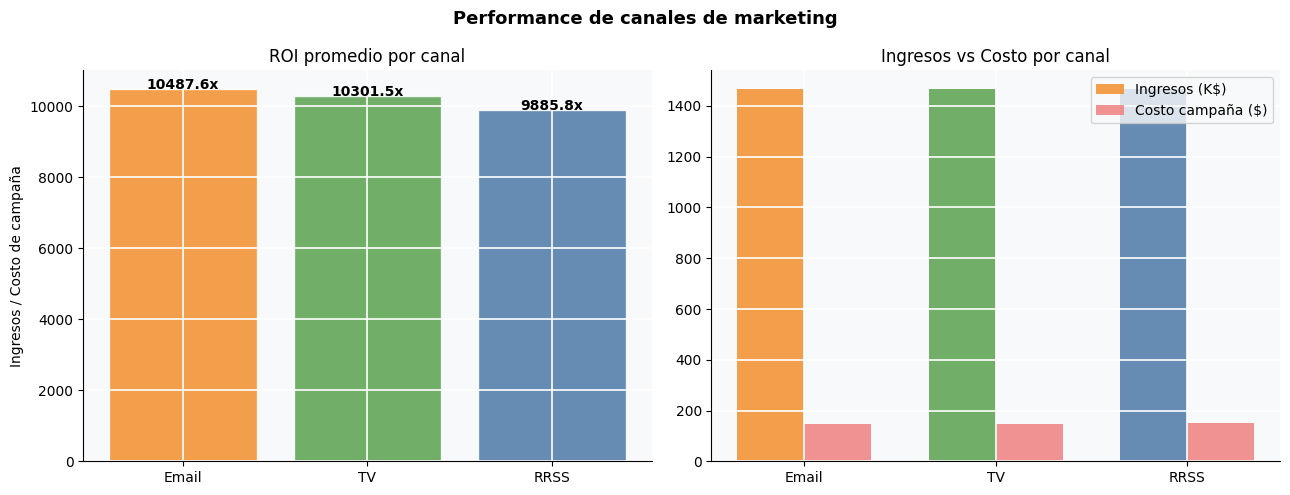

In [20]:
# ROI por canal de marketing
roi_canal = (
    ventas_marketing
    .groupby('canal')
    .agg(
        ingresos_totales=('ingresos', 'sum'),
        costo_total=('costo_total', 'sum'),
        roi_promedio=('roi', 'mean')
    )
    .reset_index()
    .sort_values('roi_promedio', ascending=False)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Performance de canales de marketing', fontsize=13, fontweight='bold')

colores_canal = {'RRSS': '#4e79a7', 'Email': '#f28e2b', 'TV': '#59a14f'}
c = [colores_canal.get(x, 'gray') for x in roi_canal['canal']]

ax1.bar(roi_canal['canal'], roi_canal['roi_promedio'], color=c, edgecolor='white', alpha=0.85)
ax1.set_title('ROI promedio por canal')
ax1.set_ylabel('Ingresos / Costo de campaña')
for i, (canal, roi) in enumerate(zip(roi_canal['canal'], roi_canal['roi_promedio'])):
    ax1.text(i, roi + 0.5, f'{roi:.1f}x', ha='center', fontweight='bold')

x = range(len(roi_canal))
w = 0.35
ax2.bar([i - w/2 for i in x], roi_canal['ingresos_totales'] / 1000,
        width=w, label='Ingresos (K$)', color=[colores_canal.get(c, 'gray') for c in roi_canal['canal']], alpha=0.85)
ax2.bar([i + w/2 for i in x], roi_canal['costo_total'],
        width=w, label='Costo campaña ($)', color='lightcoral', alpha=0.85)
ax2.set_xticks(list(x))
ax2.set_xticklabels(roi_canal['canal'])
ax2.set_title('Ingresos vs Costo por canal')
ax2.legend()

plt.tight_layout()
plt.savefig('marketing_roi.png', dpi=150, bbox_inches='tight')
plt.show()

**Nota metodológica — ROI de campañas:**

El ROI calculado (ingresos / costo de campaña) muestra valores
muy elevados y similares entre canales debido a que los costos
de campaña registrados son bajos en términos absolutos.
Esto limita la utilidad del ROI como métrica discriminadora
entre canales en este dataset.

Para un análisis más robusto en un entorno real se recomienda:

- Incluir costos indirectos de cada canal (producción, agencia, etc.)
- Considerar el costo por adquisición de cliente (CAC)
- Analizar la tasa de conversión por canal, no solo los ingresos generados

Los tres canales — Email, TV y RRSS — muestran ingresos totales
similares, lo que sugiere que ninguno domina claramente.
La decisión de priorizar uno sobre otro debería basarse en
datos de conversión y costos completos, no disponibles en este dataset.


---

## 9. Dashboard interactivo con Plotly


In [21]:
import sys
!{sys.executable} -m pip install nbformat

In [31]:
# Dashboard: 4 gráficos en un solo layout interactivo
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Ingresos mensuales por categoría',
        'Participación en ingresos totales',
        'Precio vs Ingreso por transacción',
        'ROI por canal de marketing'
    ],
    specs=[
        [{'type': 'bar'}, {'type': 'pie'}],
        [{'type': 'scatter'}, {'type': 'bar'}]
    ]
)

# 1. Barras apiladas: ingresos mensuales por categoría
pivot_mensual = ventas_clean.pivot_table(
    values='ingreso_total', index='mes_num', columns='categoria', aggfunc='sum'
).reset_index()
mes_labels = [meses[i-1] for i in pivot_mensual['mes_num']]

colores_cat = {'Electrónica': '#4e79a7', 'Electrodomésticos': '#f28e2b', 'Decoración': '#59a14f'}
for cat in ['Electrónica', 'Electrodomésticos', 'Decoración']:
    if cat in pivot_mensual.columns:
        fig.add_trace(
            go.Bar(name=cat, x=mes_labels, y=pivot_mensual[cat],
                   marker_color=colores_cat[cat], showlegend=True),
            row=1, col=1
        )

# 2. Torta: participación
fig.add_trace(
    go.Pie(labels=por_categoria['categoria'], values=por_categoria['ingresos'],
           hole=0.35, marker_colors=list(colores_cat.values()),
           showlegend=False),
    row=1, col=2
)

# 3. Scatter: precio vs ingreso
for cat, grupo in ventas_clean.groupby('categoria'):
    fig.add_trace(
        go.Scatter(
            x=grupo['precio'], y=grupo['ingreso_total'],
            mode='markers', name=cat,
            marker=dict(color=colores_cat[cat], size=5, opacity=0.5),
            showlegend=False
        ),
        row=2, col=1
    )

# 4. ROI por canal
fig.add_trace(
    go.Bar(
        x=roi_canal['canal'], y=roi_canal['roi_promedio'],
        marker_color=['#4e79a7', '#f28e2b', '#59a14f'],
        text=roi_canal['roi_promedio'].round(1),
        textposition='outside',
        showlegend=False
    ),
    row=2, col=2
)

fig.update_layout(
    title_text='📊 Dashboard de Ventas y Marketing — SynthData 2024',
    title_font_size=16,
    height=700,
    barmode='stack',
    template='plotly_white',
    legend=dict(orientation='h', y=1.08, x=0)
)

fig.update_xaxes(title_text='Mes', row=1, col=1)
fig.update_yaxes(title_text='Ingresos ($)', row=1, col=1)
fig.update_xaxes(title_text='Precio ($)', row=2, col=1)
fig.update_yaxes(title_text='Ingreso por transacción ($)', row=2, col=1)
fig.update_yaxes(title_text='ROI (Ingresos/Costo)', row=2, col=2)

fig.show()
fig.write_html('dashboard_interactivo.html')

**Interpretación del dashboard**

**Ingresos mensuales por categoría:** Las tres categorías mantienen
una contribución estable a lo largo del año. Mayo es el mes pico
con aproximadamente $145K en ingresos totales, impulsado principalmente
por Electrodomésticos. El segundo semestre muestra una caída consistente
por debajo de los $120K mensuales — patrón que sugiere estacionalidad
en la primera mitad del año.

**Participación en ingresos totales:** El negocio está notablemente
diversificado — Electrodomésticos (34.4%), Electrónica (32.9%) y
Decoración (32.7%) con apenas 2 puntos de diferencia entre la primera
y la última. Esto reduce el riesgo de dependencia de una sola categoría,
aunque también indica que no hay una categoría estrella clara para potenciar.

**Precio vs Ingreso por transacción:** La correlación positiva confirma
que el ingreso por transacción está determinado principalmente por el
precio unitario del producto. Las líneas diagonales representan los
distintos niveles de cantidad comprada — cada diagonal es una cantidad
fija multiplicada por el rango de precios.

**ROI por canal de marketing:** Los tres canales — Email, TV y RRSS —
muestran retornos similares en este período. La decisión de priorizar
un canal sobre otro debería complementarse con métricas de conversión
y alcance no disponibles en este dataset.


---

## 10. Análisis demográfico de clientes


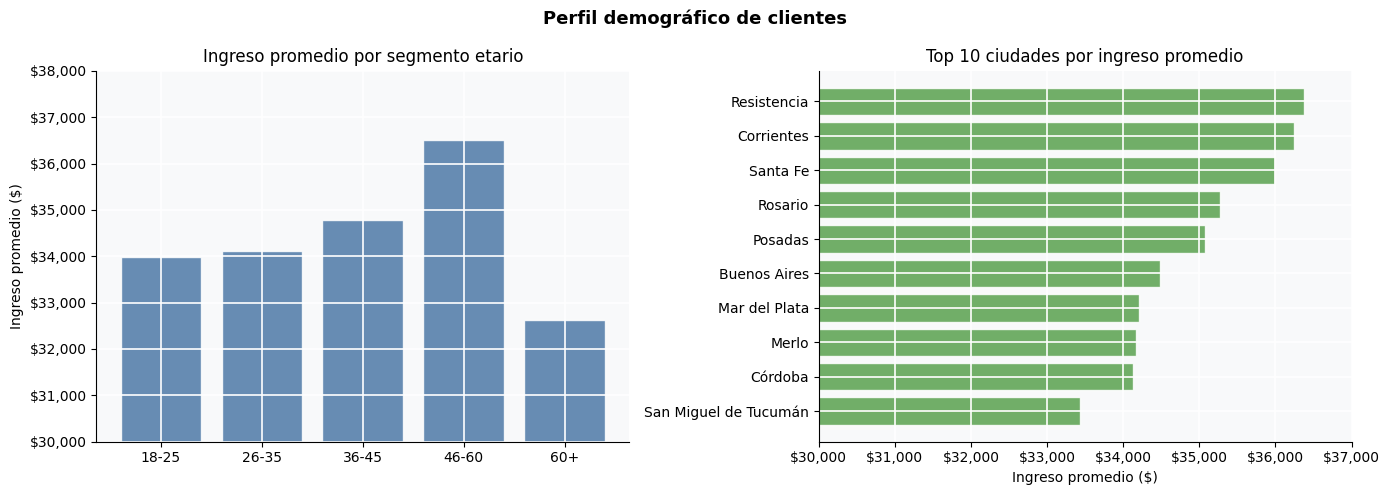

In [27]:
# Ingreso promedio por segmento etario
ingreso_segmento = (
    clientes_clean
    .groupby('segmento_edad', observed=True)
    .agg(
        ingreso_promedio=('ingresos', 'mean'),
        ingreso_mediano=('ingresos', 'median'),
        cantidad=('id_cliente', 'count')
    )
    .reset_index()
)

# Top 10 ciudades por ingreso promedio
top_ciudades = (
    clientes_clean
    .groupby('ciudad')
    .agg(ingreso_promedio=('ingresos', 'mean'), clientes=('id_cliente', 'count'))
    .query('clientes >= 5')  # solo ciudades con muestra representativa
    .sort_values('ingreso_promedio', ascending=False)
    .head(10)
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perfil demográfico de clientes', fontsize=13, fontweight='bold')

# Ingreso por segmento
ax1.bar(ingreso_segmento['segmento_edad'].astype(str),
        ingreso_segmento['ingreso_promedio'],
        color='#4e79a7', alpha=0.85, edgecolor='white')
ax1.set_title('Ingreso promedio por segmento etario')
ax1.set_ylabel('Ingreso promedio ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_ylim(30000, 38000)

# Top ciudades
ax2.barh(top_ciudades['ciudad'], top_ciudades['ingreso_promedio'],
         color='#59a14f', alpha=0.85, edgecolor='white')
ax2.set_title('Top 10 ciudades por ingreso promedio')
ax2.set_xlabel('Ingreso promedio ($)')
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_xlim(30000, 37000)

plt.tight_layout()
plt.savefig('demografico_clientes.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación — Perfil demográfico de clientes**

**Ingreso por segmento etario:** El segmento 46-60 años concentra
el mayor ingreso promedio (~$36.500), seguido por 36-45 (~$34.800).
Los segmentos más jóvenes (18-25 y 26-35) y el de mayor edad (60+)
muestran ingresos menores. La diferencia total entre el segmento
más alto y el más bajo es de aproximadamente $4.000 — relativamente
acotada, lo que indica una base de clientes homogénea en términos
de poder adquisitivo.

**Top ciudades por ingreso promedio:** Resistencia y Corrientes
lideran el ranking con ingresos promedio superiores a $36.000,
seguidas por Santa Fe y Rosario. Buenos Aires aparece en la
posición 6, por debajo de ciudades del interior — lo cual podría
reflejar la composición específica de la base de clientes actual
más que una tendencia general del mercado.

**Recomendación:** El segmento 46-60 años representa el cliente
con mayor poder adquisitivo. Las campañas de productos premium
deberían orientarse prioritariamente a este grupo. Geográficamente,
el interior del país muestra ingresos promedio competitivos con
Buenos Aires — una oportunidad para expandir acciones comerciales
más allá del AMBA.


---

## 11. Conclusiones e insights

A continuación se resumen los hallazgos clave del análisis con su implicancia para el negocio.


In [30]:
# Resumen ejecutivo automático
ingreso_total    = ventas_clean['ingreso_total'].sum()
cat_top          = por_categoria.iloc[0]['categoria']
cat_top_pct      = por_categoria.iloc[0]['participacion_%']
producto_top     = top_productos.iloc[0]['producto']
mes_pico         = meses[ventas_mensuales['ingresos'].idxmax()]
canal_roi_top    = roi_canal.iloc[0]['canal']
roi_top_valor    = roi_canal.iloc[0]['roi_promedio']

print('=' * 55)
print('  RESUMEN EJECUTIVO — SynthData Analytics 2024')
print('=' * 55)
print(f'\n  Ingreso total anual:     ${ingreso_total:>12,.0f}')
print(f'  Total transacciones:     {len(ventas_clean):>12,}')
print(f'  Ticket promedio:         ${ventas_clean["ingreso_total"].mean():>12,.2f}')
print(f'\n  Categoría líder:         {cat_top} ({cat_top_pct}% del ingreso)')
print(f'  Producto más vendido:    {producto_top}')
print(f'  Mes pico de ventas:      {mes_pico}')
print(f'\n  Canal con mayor ROI:     {canal_roi_top} ({roi_top_valor:.1f}x retorno)')
print()
print('  RECOMENDACIONES:')
print(f'  1. Reforzar stock de {producto_top} previo al mes de {mes_pico}.')
print(f'  2. Priorizar inversión en {canal_roi_top} para próximas campañas.')
print(f'  3. Analizar por qué {por_categoria.iloc[-1]["categoria"]} tiene')
print(f'     menor participación y evaluar acciones de impulso.')
print(f'  4. Estudiar el segmento etario con mayor ingreso para')
print(f'     orientar comunicación de productos premium.')
print('=' * 55)

  RESUMEN EJECUTIVO — SynthData Analytics 2024

  Ingreso total anual:     $   1,467,094
  Total transacciones:            2,998
  Ticket promedio:         $      489.36

  Categoría líder:         Electrodomésticos (34.4% del ingreso)
  Producto más vendido:    Lámpara de mesa
  Mes pico de ventas:      May

  Canal con mayor ROI:     Email (10487.6x retorno)

  RECOMENDACIONES:
  1. Reforzar stock de Lámpara de mesa previo al mes de May.
  2. Priorizar inversión en Email para próximas campañas.
  3. Analizar por qué Decoración tiene
     menor participación y evaluar acciones de impulso.
  4. Estudiar el segmento etario con mayor ingreso para
     orientar comunicación de productos premium.


---

## Anexo

### Archivos incluidos en el proyecto

| Archivo                      | Descripción                                               |
| ---------------------------- | --------------------------------------------------------- |
| `ventas.csv`                 | Dataset original de transacciones de ventas (3.035 filas) |
| `marketing.csv`              | Dataset original de campañas de marketing (90 filas)      |
| `clientes.csv`               | Dataset original de perfiles de clientes (567 filas)      |
| `SynthData_Analytics.ipynb`  | Este notebook con el análisis completo                    |
| `ventas_mensuales.png`       | Gráfico de evolución mensual                              |
| `ventas_categoria.png`       | Distribución por categoría                                |
| `top_productos.png`          | Top 10 productos                                          |
| `distribuciones.png`         | Histogramas de variables clave                            |
| `correlacion.png`            | Mapa de correlación y scatter                             |
| `seaborn_avanzado.png`       | Boxplot y heatmap avanzados                               |
| `marketing_roi.png`          | Análisis ROI por canal                                    |
| `demografico_clientes.png`   | Perfil demográfico                                        |
| `dashboard_interactivo.html` | Dashboard interactivo de ventas y marketing (Plotly)      |

### Stack tecnológico

- **Python 3.13** — lenguaje base
- **pandas 3.x** — manipulación y análisis de datos
- **numpy** — operaciones numéricas
- **matplotlib** — visualización estática
- **seaborn** — visualización estadística
- **plotly** — dashboard interactivo

### Metodología

El análisis siguió el ciclo estándar de data analytics: **recopilación → diagnóstico de calidad → limpieza documentada → análisis exploratorio → estadística descriptiva → correlación → visualización → integración de fuentes → conclusiones accionables**.
